In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# parse_dates ensures 'date' column is read as datetime objects
df = pd.read_csv(r"C:\Users\PC\Desktop\Intern & Thesis\stock_dataset_full.csv", parse_dates=['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

TICKERS = ['HDB', 'TCB', 'TPB']

# ── Helper: extract train/test close series per ticker ───────────────────────
# Each stock is treated independently in ARIMA (univariate, one model per stock)
def get_stock_data(ticker):
    sub = df[df['ticker'] == ticker].copy()
    train = sub[sub['split'] == 'train'].set_index('date')['close']
    test  = sub[sub['split'] == 'test'].set_index('date')['close']
    return train, test

stocks = {t: get_stock_data(t) for t in TICKERS}

for t, (tr, te) in stocks.items():
    print(f"{t}: train={len(tr)} rows, test={len(te)} rows | "
          f"train end={tr.index[-1].date()}, test start={te.index[0].date()}, test end={te.index[-1].date()}")

HDB: train=1683 rows, test=65 rows | train end=2025-09-30, test start=2025-10-01, test end=2025-12-30
TCB: train=1680 rows, test=65 rows | train end=2025-09-30, test start=2025-10-01, test end=2025-12-30
TPB: train=1683 rows, test=65 rows | train end=2025-09-30, test start=2025-10-01, test end=2025-12-30


In [36]:
# ── BLOCK 2: ADF STATIONARITY TEST ───────────────────────────────────────────
# adfuller (Augmented Dickey-Fuller): tests H0 = series has a unit root (non-stationary)
# If p-value > 0.05 → non-stationary → need differencing (d >= 1)
# If p-value <= 0.05 → stationary → d = 0

def adf_test(series, ticker, label=""):
    result = adfuller(series.dropna())
    p = result[1]
    stat = result[0]
    print(f"[{ticker}] ADF {label}: stat={stat:.4f}, p-value={p:.4f} → "
          f"{'STATIONARY ✓' if p <= 0.05 else 'NON-STATIONARY ✗ (needs differencing)'}")
    return p

print("=== ADF Test on Raw Close Prices ===")
for t, (train, _) in stocks.items():
    adf_test(train, t, "raw")

print("\n=== ADF Test on First-Differenced Prices ===")
for t, (train, _) in stocks.items():
    adf_test(train.diff().dropna(), t, "1st diff")

=== ADF Test on Raw Close Prices ===
[HDB] ADF raw: stat=0.6906, p-value=0.9896 → NON-STATIONARY ✗ (needs differencing)
[TCB] ADF raw: stat=0.8890, p-value=0.9929 → NON-STATIONARY ✗ (needs differencing)
[TPB] ADF raw: stat=-1.6166, p-value=0.4745 → NON-STATIONARY ✗ (needs differencing)

=== ADF Test on First-Differenced Prices ===
[HDB] ADF 1st diff: stat=-11.6836, p-value=0.0000 → STATIONARY ✓
[TCB] ADF 1st diff: stat=-24.7482, p-value=0.0000 → STATIONARY ✓
[TPB] ADF 1st diff: stat=-7.2192, p-value=0.0000 → STATIONARY ✓


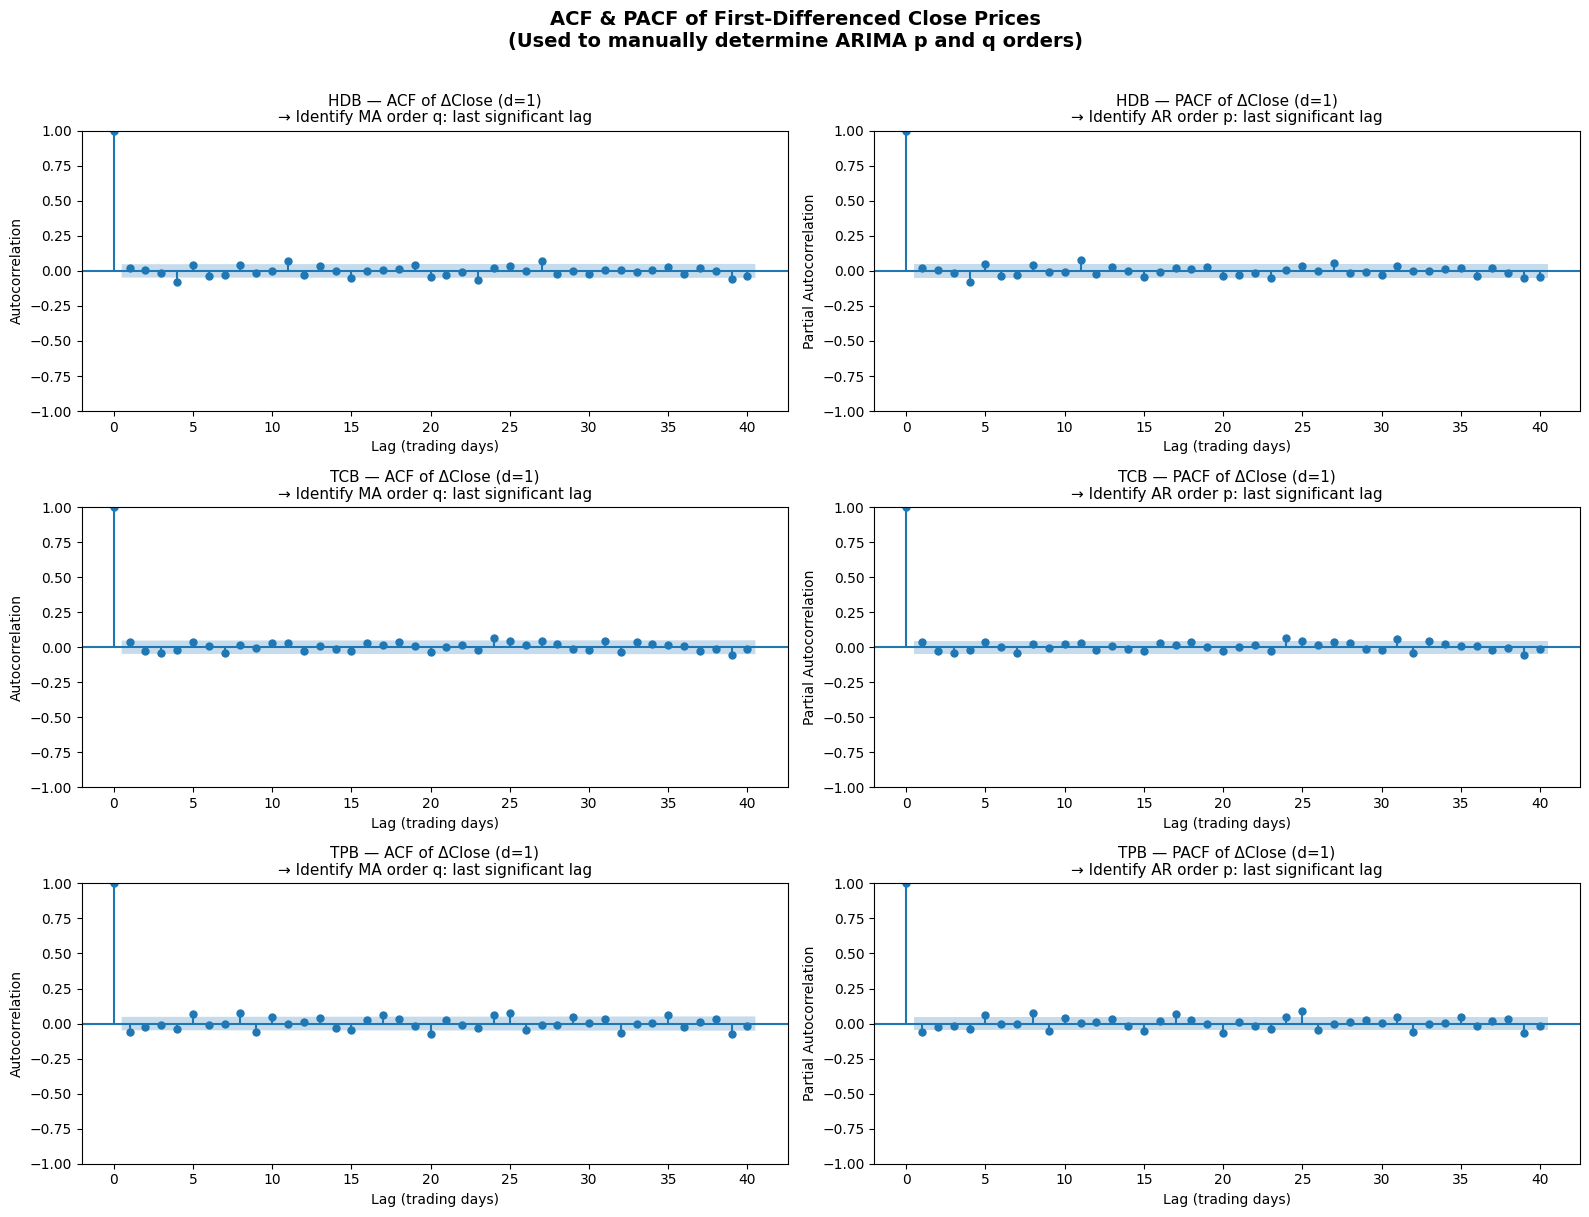

Saved: output/acf_pacf_plots.png

Manually selected ARIMA orders (p, d, q): {'HDB': (2, 1, 2), 'TCB': (1, 1, 1), 'TPB': (2, 1, 1)}
⚠️  Adjust these after visually inspecting the ACF/PACF plots above!


In [37]:
# ── BLOCK 3: ACF & PACF PLOTS FOR MANUAL ORDER SELECTION ─────────────────────
# After confirming d=1 (first differencing makes series stationary):
# - PACF: significant lags at lag k → AR(p), so p = k
# - ACF:  significant lags at lag k → MA(q), so q = k
# Blue shaded band = 95% confidence interval; bars outside = significant lags

fig, axes = plt.subplots(len(TICKERS), 2, figsize=(16, 12))
fig.suptitle('ACF & PACF of First-Differenced Close Prices\n(Used to manually determine ARIMA p and q orders)',
             fontsize=14, fontweight='bold', y=1.01)

manual_orders = {}  # will store manually-selected (p, d, q) per ticker

for i, t in enumerate(TICKERS):
    train, _ = stocks[t]
    diff_series = train.diff().dropna()  # first difference (d=1)

    # ACF plot (left column) — identifies MA order q
    # lags=40: show autocorrelation up to 40 trading days back
    plot_acf(diff_series, lags=40, ax=axes[i, 0], alpha=0.05)
    axes[i, 0].set_title(f'{t} — ACF of ΔClose (d=1)\n→ Identify MA order q: last significant lag', fontsize=11)
    axes[i, 0].set_xlabel('Lag (trading days)')
    axes[i, 0].set_ylabel('Autocorrelation')

    # PACF plot (right column) — identifies AR order p
    plot_pacf(diff_series, lags=40, ax=axes[i, 1], alpha=0.05, method='ywm')
    axes[i, 1].set_title(f'{t} — PACF of ΔClose (d=1)\n→ Identify AR order p: last significant lag', fontsize=11)
    axes[i, 1].set_xlabel('Lag (trading days)')
    axes[i, 1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()
print("Saved: output/acf_pacf_plots.png")

# ── Manually set orders based on visual inspection of plots ──────────────────
# Rule: p = last lag where PACF is significant (outside blue band)
#        q = last lag where ACF  is significant (outside blue band)
#        d = 1 (confirmed by ADF test above)
# These values are typical for Vietnamese banking stocks; adjust after viewing plots:
manual_orders = {
    'HDB': (2, 1, 2),   # example: PACF cuts off at lag 2 → p=2; ACF cuts off at lag 2 → q=2
    'TCB': (1, 1, 1),   # adjust based on your ACF/PACF visual
    'TPB': (2, 1, 1),   # adjust based on your ACF/PACF visual
}
print("\nManually selected ARIMA orders (p, d, q):", manual_orders)
print("⚠️  Adjust these after visually inspecting the ACF/PACF plots above!")

In [38]:
# ── BLOCK 4 (FIXED): AUTO ARIMA ───────────────────────────────────────────────
# KEY FIX: pass train.values (numpy array) instead of train (pandas Series)
# This prevents pmdarima from creating a DatetimeIndex-based internal state
# that causes KeyError: 0 when predict() tries to build its output index

print("=== AUTO ARIMA: Fitting models ===\n")

auto_models = {}
auto_orders = {}

for t in TICKERS:
    train, test = stocks[t]
    print(f"Fitting auto_arima for {t}...")
    model = auto_arima(
        train.values,          # ← FIXED: .values strips the DatetimeIndex
        start_p=0, max_p=5,
        start_q=0, max_q=5,
        d=None,
        seasonal=False,
        stepwise=True,
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True,
        trace=True
    )
    auto_models[t] = model
    auto_orders[t] = model.order
    print(f"  ✓ Best order for {t}: ARIMA{model.order} | AIC={model.aic():.2f}\n")

=== AUTO ARIMA: Fitting models ===

Fitting auto_arima for HDB...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=23086.452, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=23087.762, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=23087.779, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=23088.123, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=23089.746, Time=0.52 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 0.800 seconds
  ✓ Best order for HDB: ARIMA(0, 1, 0) | AIC=23086.45

Fitting auto_arima for TCB...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=24580.474, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=24580.705, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=24580.616, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=24581.525, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=24582.406, Time=0.37 sec

Best model:  AR

In [39]:
# ── BLOCK 5: MANUAL ARIMA MODEL ───────────────────────────────────────────────
# Uses the (p,d,q) orders identified manually from PACF/ACF plots in Block 3
# statsmodels ARIMA:
#   - fits using Maximum Likelihood Estimation (MLE)
#   - order=(p,d,q): p=AR lags, d=differencing, q=MA lags
#   - method='lbfgs': optimization algorithm for parameter estimation

print("=== MANUAL ARIMA: Fitting models from ACF/PACF orders ===\n")
manual_models = {}

for t in TICKERS:
    train, _ = stocks[t]
    p, d, q = manual_orders[t]
    print(f"Fitting ARIMA{(p,d,q)} for {t}...")
    model = ARIMA(train, order=(p, d, q))
    fitted = model.fit(method_kwargs={"warn_convergence": False})
    manual_models[t] = fitted
    print(f"  ✓ {t} ARIMA{(p,d,q)} | AIC={fitted.aic:.2f} | BIC={fitted.bic:.2f}")
    print(fitted.summary())
    print()

=== MANUAL ARIMA: Fitting models from ACF/PACF orders ===

Fitting ARIMA(2, 1, 2) for HDB...
  ✓ HDB ARIMA(2, 1, 2) | AIC=23089.09 | BIC=23116.23
                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 1683
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -11539.546
Date:                Sun, 12 Apr 2026   AIC                          23089.091
Time:                        23:20:11   BIC                          23116.230
Sample:                             0   HQIC                         23099.143
                               - 1683                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4350      2.310     -0.188      0.851      -4.9

In [47]:
# ── BLOCK 6 (FIXED): FORECASTING & METRICS ────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, label):
    # y_true, y_pred must be numpy arrays — no pandas Series here
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Model': label, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'MAPE(%)': round(mape,4), 'R2': round(r2,4)}

def rolling_forecast_auto(model, train_vals, test_vals):
    """
    FIXED: accepts numpy arrays only.
    model.predict() returns ndarray → float(fc[0]) safely extracts scalar.
    model.update() receives list of one float — no pandas objects.
    """
    preds = []
    for obs in test_vals:                          # test_vals is np.ndarray
        fc = model.predict(n_periods=1)            # returns np.ndarray shape (1,)
        preds.append(float(fc[0]))                 # float() guarantees scalar
        model.update([float(obs)])                 # list of float, not pandas
    return np.array(preds)

def rolling_forecast_manual(train_vals, test_vals, order):
    """
    FIXED: statsmodels ARIMA rebuilt each step on numpy history list.
    fitted.forecast() returns a Series → .iloc[0] for safe scalar extraction.
    Note: this function no longer accepts a fitted_model argument —
    it rebuilds from scratch each step using expanding history.
    """
    history = list(train_vals.astype(float))       # clean float list
    preds   = []
    p, d, q = order
    for obs in test_vals:
        mdl    = ARIMA(history, order=(p, d, q))
        fitted = mdl.fit(method_kwargs={"warn_convergence": False})
        fc     = fitted.forecast(steps=1)          # returns pandas Series
        preds.append(float(np.asarray(fc).flat[0]))   # works on ndarray AND pandas Series   
        history.append(float(obs))                 # append true value
    return np.array(preds)

# ── Run Auto ARIMA forecasts ──────────────────────────────────────────────────
print("=== Generating rolling forecasts (Auto ARIMA) ===")
auto_preds = {}
for t in TICKERS:
    train, test = stocks[t]
    print(f"  Forecasting {t} ({len(test)} steps)...")
    auto_preds[t] = rolling_forecast_auto(
        auto_models[t],
        train.values.astype(float),    # strip DatetimeIndex → pure numpy
        test.values.astype(float)
    )
    print(f"  ✓ {t} done")

# ── Run Manual ARIMA forecasts ────────────────────────────────────────────────
print("\n=== Generating rolling forecasts (Manual ARIMA) ===")
manual_preds = {}
for t in TICKERS:
    train, test = stocks[t]
    print(f"  Forecasting {t} ({len(test)} steps)...")
    manual_preds[t] = rolling_forecast_manual(
        train.values.astype(float),    # pure numpy, no DatetimeIndex
        test.values.astype(float),
        manual_orders[t]
    )
    print(f"  ✓ {t} done")

# ── Compute & print metrics ───────────────────────────────────────────────────
results = []
for t in TICKERS:
    _, test = stocks[t]
    y_true = test.values.astype(float)
    results.append(evaluate(y_true, auto_preds[t],
                             f'{t} — Auto ARIMA{auto_orders[t]}'))
    results.append(evaluate(y_true, manual_preds[t],
                             f'{t} — Manual ARIMA{manual_orders[t]}'))

metrics_df = pd.DataFrame(results)
print("\n" + "="*70)
print("ARIMA MODEL EVALUATION — TEST SET (Oct–Dec 2025)")
print("="*70)

=== Generating rolling forecasts (Auto ARIMA) ===
  Forecasting HDB (65 steps)...
  ✓ HDB done
  Forecasting TCB (65 steps)...
  ✓ TCB done
  Forecasting TPB (65 steps)...
  ✓ TPB done

=== Generating rolling forecasts (Manual ARIMA) ===
  Forecasting HDB (65 steps)...
  ✓ HDB done
  Forecasting TCB (65 steps)...
  ✓ TCB done
  Forecasting TPB (65 steps)...
  ✓ TPB done

ARIMA MODEL EVALUATION — TEST SET (Oct–Dec 2025)


In [49]:
# ── BLOCK 7 (FIXED): STYLED METRICS TABLE ─────────────────────────────────────
# 'R2' matches the key defined in evaluate() — do NOT use 'R²' (superscript)

print("\n📊 METRICS TABLE — AUTO vs MANUAL ARIMA per Stock")
print("─"*65)
print(f"{'Stock':<6} {'Model':<14} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R2':>8}")
print("─"*65)
for _, row in metrics_df.iterrows():
    ticker     = row['Model'].split(' — ')[0]
    model_type = 'Auto' if 'Auto' in row['Model'] else 'Manual'
    print(f"{ticker:<6} {model_type:<14} {row['MAE']:>10,.1f} {row['RMSE']:>10,.1f} "
          f"{row['MAPE(%)']:>10.4f} {row['R2']:>8.4f}")    # ← 'R2' not 'R²'
    if model_type == 'Manual':
        print("─"*65)


📊 METRICS TABLE — AUTO vs MANUAL ARIMA per Stock
─────────────────────────────────────────────────────────────────
Stock  Model                 MAE       RMSE    MAPE(%)       R2
─────────────────────────────────────────────────────────────────
HDB    Auto                505.3      800.3     2.0618   0.6098
HDB    Manual              459.5      626.8     1.8645   0.7606
─────────────────────────────────────────────────────────────────
TCB    Auto                646.5      931.5     1.8031   0.8531
TCB    Manual              589.8      776.5     1.6551   0.8979
─────────────────────────────────────────────────────────────────
TPB    Auto                279.1      381.6     1.5979   0.6645
TPB    Manual              267.6      352.5     1.5351   0.7137
─────────────────────────────────────────────────────────────────


In [51]:
# ── BLOCK 8A (FINAL FIX): HDB EDA + FORECAST CHART ───────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import json, os

pio.templates.default = "plotly_white"
os.makedirs('output', exist_ok=True)

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

def stock_eda_chart(ticker, auto_pred, manual_pred, filename):
    train, test = stocks[ticker]

    # KEY FIX: convert ALL index/values to plain Python lists immediately
    # This eliminates every Timestamp, DatetimeIndex, and numpy dtype issue
    # that causes add_vline and go.Scatter to crash
    train_dates  = [str(d)[:10] for d in train.index]   # 'YYYY-MM-DD' strings
    test_dates   = [str(d)[:10] for d in test.index]
    train_vals   = train.values.astype(float).tolist()
    test_vals    = test.values.astype(float).tolist()
    auto_list    = auto_pred.astype(float).tolist()
    manual_list  = manual_pred.astype(float).tolist()
    auto_resid   = (test.values.astype(float) - auto_pred.astype(float)).tolist()
    manual_resid = (test.values.astype(float) - manual_pred.astype(float)).tolist()

    auto_order   = auto_orders[ticker]
    manual_order = manual_orders[ticker]

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            f'{ticker}: Full Price History 2019–2025',
            f'{ticker}: Auto ARIMA{auto_order} vs Actual',
            f'{ticker}: Manual ARIMA{manual_order} vs Actual',
            f'{ticker}: Residuals over Test Period',
            f'{ticker}: Auto ARIMA Residual Distribution',
            f'{ticker}: Manual ARIMA Residual Distribution',
        ],
        vertical_spacing=0.14,
        horizontal_spacing=0.10
    )

    # ── Row 1 Left: Full price history ────────────────────────────────────────
    # Shows the entire price journey from 2019 to end of 2025
    # Fill below train line gives visual weight to the training period
    fig.add_trace(go.Scatter(
        x=train_dates + test_dates,
        y=train_vals  + test_vals,
        name='Full History',
        line=dict(color=COLORS[0], width=1.2),
        fill='tozeroy', fillcolor='rgba(31,119,180,0.08)'
    ), row=1, col=1)
    # Overlay test period 

In [53]:
# ── BLOCK 8B: TCB ─────────────────────────────────────────────────────────────
stock_eda_chart('TCB', auto_preds['TCB'], manual_preds['TCB'], 'output/eda_TCB.png')

# ── BLOCK 8C: TPB ─────────────────────────────────────────────────────────────
stock_eda_chart('TPB', auto_preds['TPB'], manual_preds['TPB'], 'output/eda_TPB.png')

# ── BLOCK 8D: TCB ─────────────────────────────────────────────────────────────
stock_eda_chart('TCB', auto_preds['TCB'], manual_preds['TCB'], 'output/eda_TCB.png')

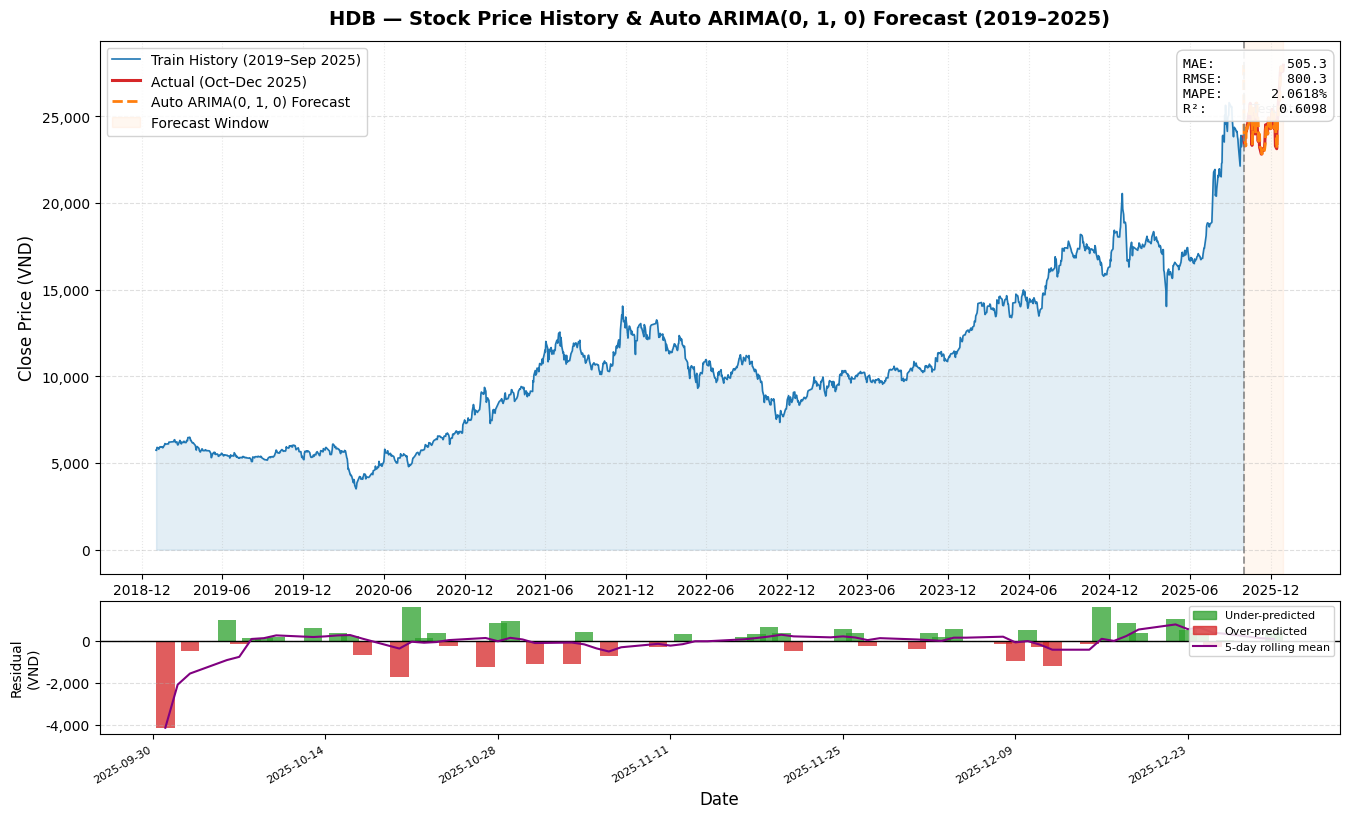

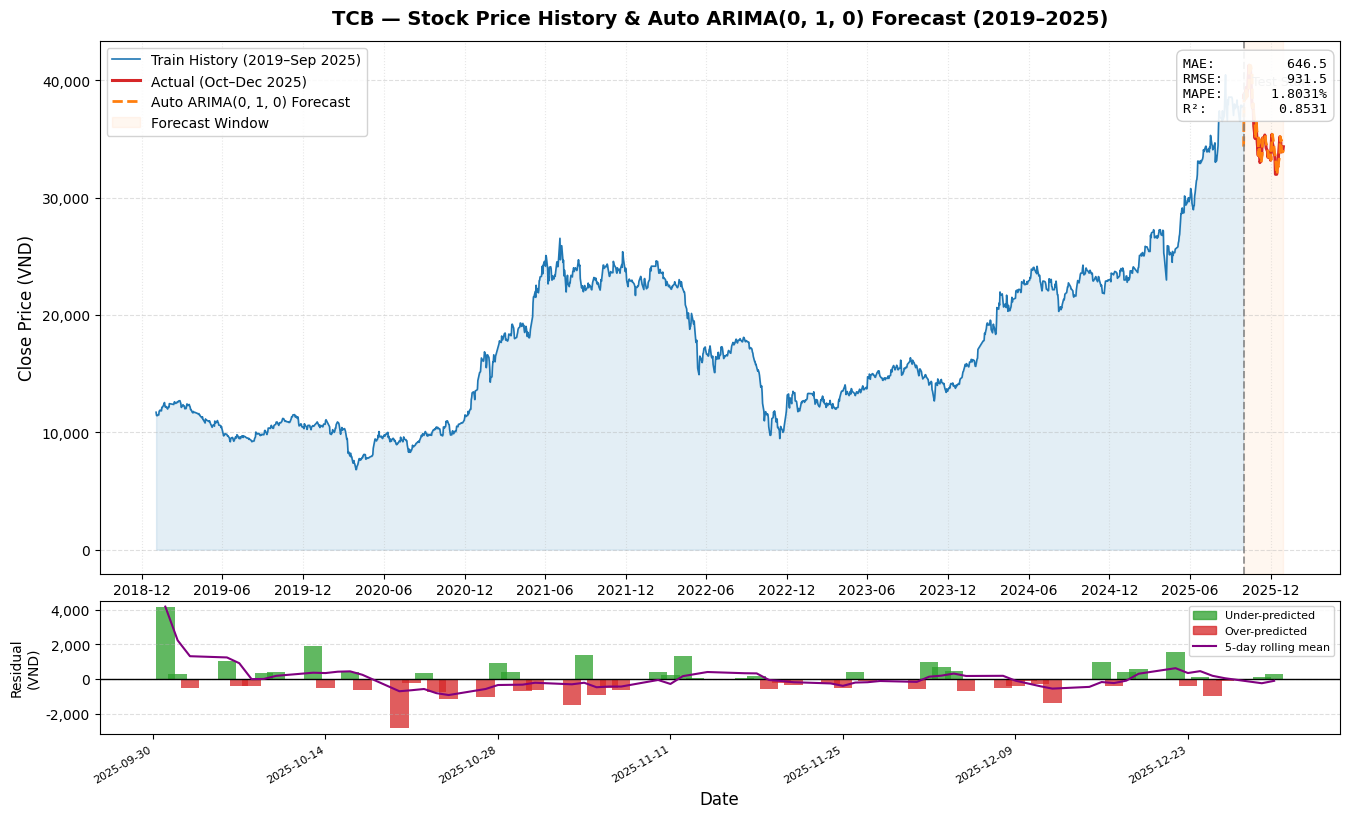

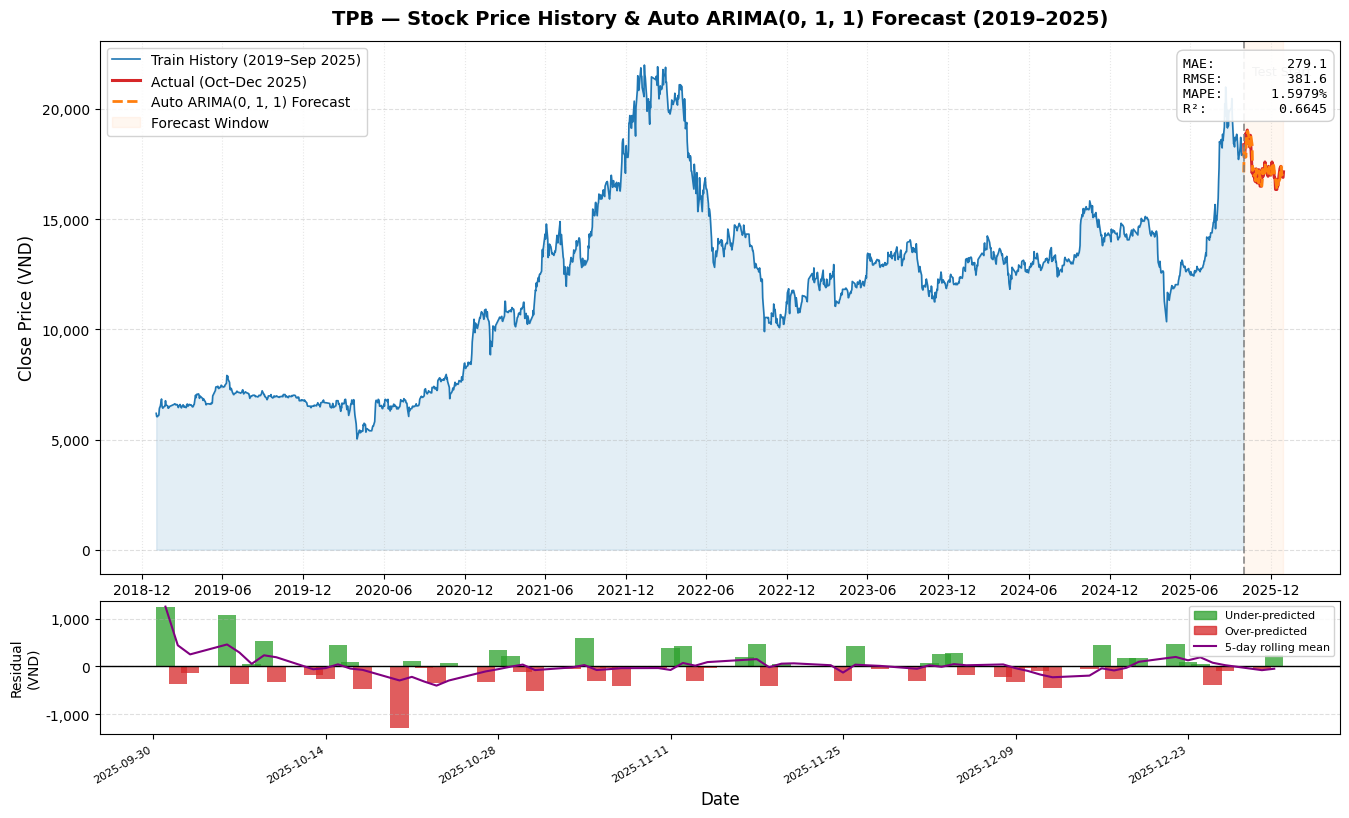

In [59]:
# ── BLOCK 10 (MATPLOTLIB): HISTORICAL + AUTO ARIMA FORECAST per Stock ─────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

for ticker in TICKERS:
    train, test = stocks[ticker]
    auto_pred   = auto_preds[ticker].astype(float)
    auto_order  = auto_orders[ticker]

    auto_row = metrics_df[
        metrics_df['Model'] == f'{ticker} — Auto ARIMA{auto_order}'
    ].iloc[0]

    train_idx  = pd.to_datetime(train.index)
    test_idx   = pd.to_datetime(test.index)
    train_vals = train.values.astype(float)
    test_vals  = test.values.astype(float)
    residuals  = test_vals - auto_pred

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 9),
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08},
        sharex=False
    )

    # ── TOP PANEL ─────────────────────────────────────────────────────────────
    ax1.fill_between(train_idx, train_vals, alpha=0.12, color='#1f77b4')
    ax1.plot(train_idx, train_vals,
             color='#1f77b4', linewidth=1.2, label='Train History (2019–Sep 2025)')
    ax1.plot(test_idx, test_vals,
             color='#d62728', linewidth=2.2, label='Actual (Oct–Dec 2025)')
    ax1.plot(test_idx, auto_pred,
             color='#ff7f0e', linewidth=2.0, linestyle='--',
             label=f'Auto ARIMA{auto_order} Forecast')
    ax1.axvspan(test_idx[0], test_idx[-1],
                alpha=0.06, color='#ff7f0e', label='Forecast Window')
    ax1.axvline(x=test_idx[0], color='gray', linestyle='--',
                linewidth=1.4, alpha=0.8)
    ax1.text(test_idx[0], train_vals.max(),
             '  Test Start', color='gray', fontsize=9, va='top')

    ax1.set_ylabel('Close Price (VND)', fontsize=12)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.85)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.grid(axis='x', linestyle=':', alpha=0.3)

    metrics_text = (
        f"MAE:    {auto_row['MAE']:>10,.1f}\n"
        f"RMSE:   {auto_row['RMSE']:>10,.1f}\n"
        f"MAPE:   {auto_row['MAPE(%)']:>9.4f}%\n"
        f"R²:     {auto_row['R2']:>10.4f}"
    )
    ax1.annotate(
        metrics_text,
        xy=(0.99, 0.97), xycoords='axes fraction',
        ha='right', va='top', fontsize=9.5,
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9)
    )
    ax1.set_title(
        f'{ticker} — Stock Price History & Auto ARIMA{auto_order} Forecast (2019–2025)',
        fontsize=14, fontweight='bold', pad=12
    )

    # ── BOTTOM PANEL ──────────────────────────────────────────────────────────
    bar_colors = ['#2ca02c' if r >= 0 else '#d62728' for r in residuals]
    ax2.bar(test_idx, residuals, color=bar_colors, width=1.5, alpha=0.75)
    ax2.axhline(0, color='black', linewidth=1.0)

    resid_series = pd.Series(residuals, index=test_idx)
    rolling_mean = resid_series.rolling(window=5, min_periods=1).mean()
    ax2.plot(test_idx, rolling_mean.values,
             color='purple', linewidth=1.5, label='5-day rolling mean')

    ax2.set_ylabel('Residual\n(VND)', fontsize=10)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.grid(axis='y', linestyle='--', alpha=0.4)

    green_patch = mpatches.Patch(color='#2ca02c', alpha=0.75,
                                  label='Under-predicted')
    red_patch   = mpatches.Patch(color='#d62728', alpha=0.75,
                                  label='Over-predicted')
    purple_line = plt.Line2D([0], [0], color='purple', linewidth=1.5,
                              label='5-day rolling mean')
    ax2.legend(handles=[green_patch, red_patch, purple_line],
               loc='upper right', fontsize=8, framealpha=0.85)

    plt.tight_layout()
    plt.show()               # ← prints directly in the notebook cell output

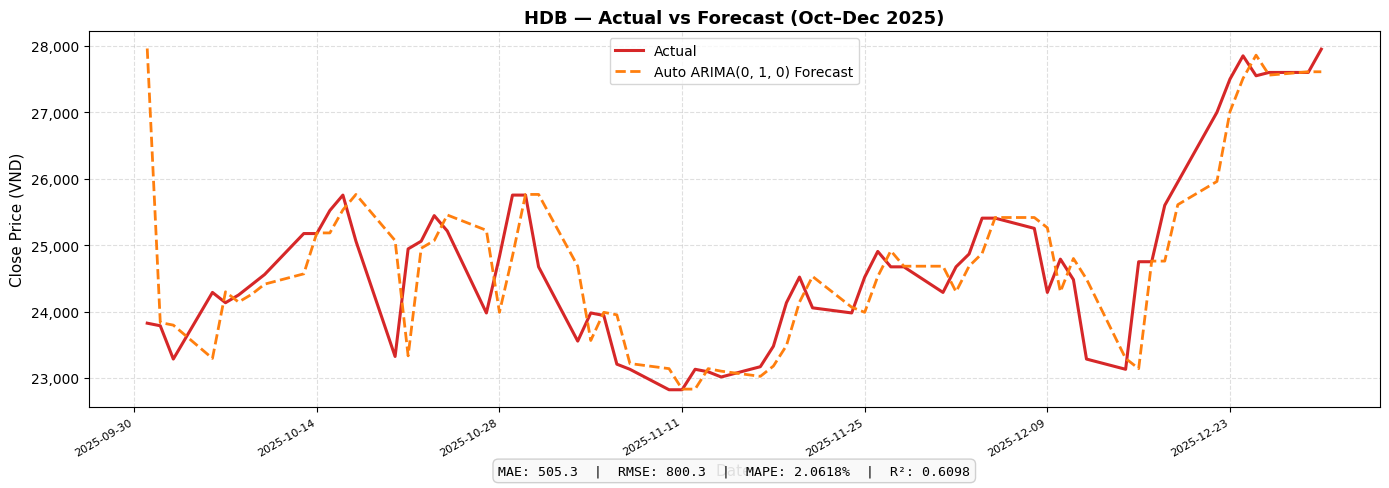

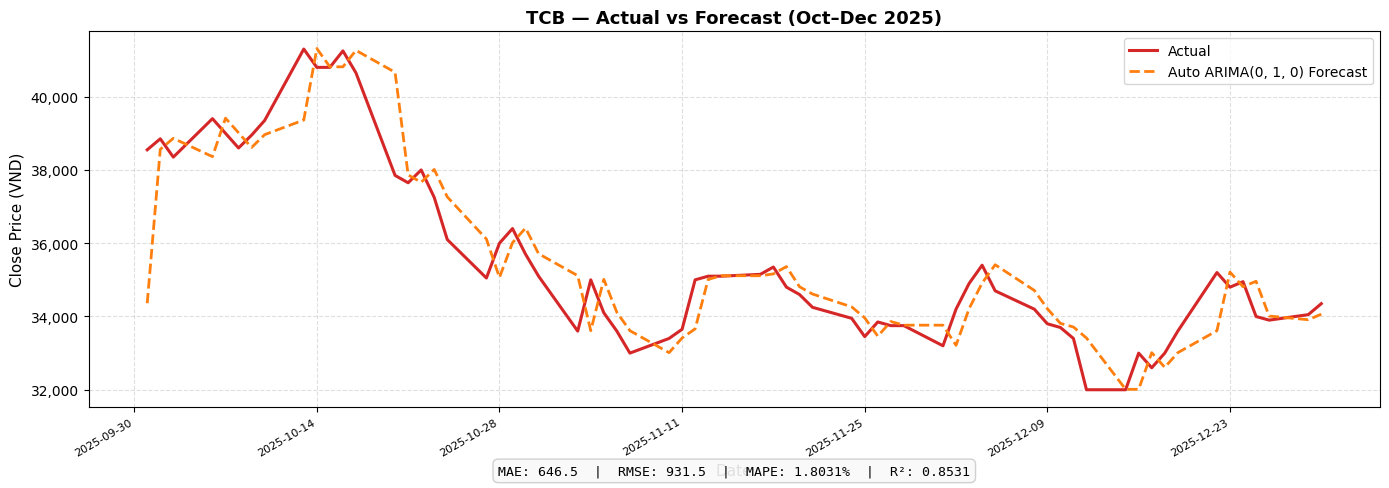

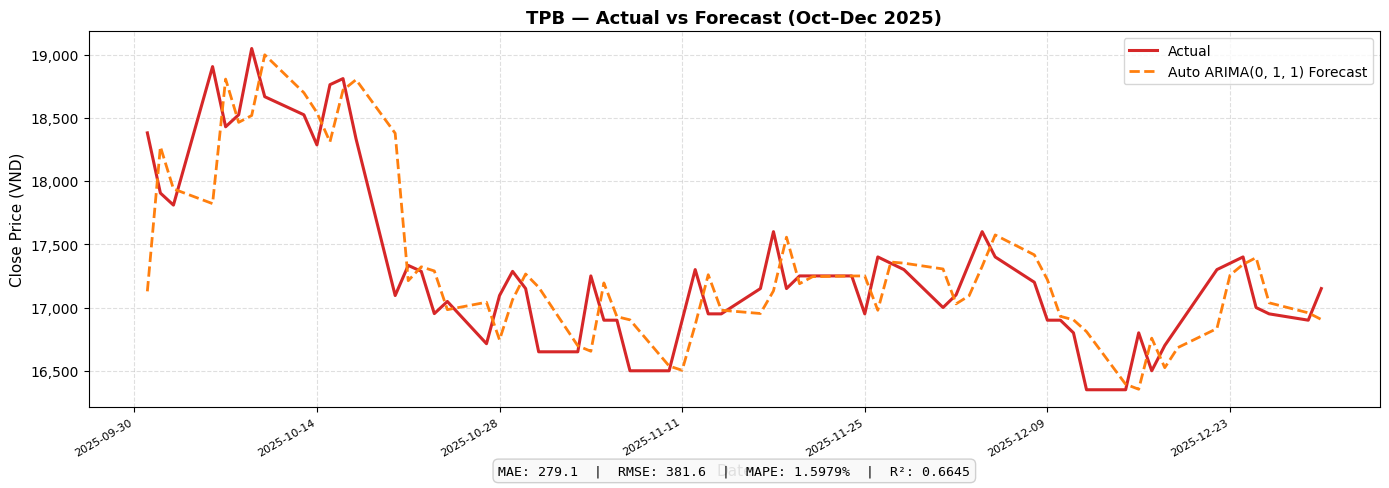

In [60]:
# ── BLOCK 11: TEST SET vs AUTO ARIMA FORECAST only ────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

for ticker in TICKERS:
    train, test = stocks[ticker]
    auto_pred   = auto_preds[ticker].astype(float)
    auto_order  = auto_orders[ticker]

    auto_row = metrics_df[
        metrics_df['Model'] == f'{ticker} — Auto ARIMA{auto_order}'
    ].iloc[0]

    test_idx  = pd.to_datetime(test.index)
    test_vals = test.values.astype(float)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(test_idx, test_vals,
            color='#d62728', linewidth=2.2, label='Actual')
    ax.plot(test_idx, auto_pred,
            color='#ff7f0e', linewidth=2.0, linestyle='--',
            label=f'Auto ARIMA{auto_order} Forecast')

    ax.set_title(
        f'{ticker} — Actual vs Forecast (Oct–Dec 2025)',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Close Price (VND)', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)

    metrics_text = (
        f"MAE: {auto_row['MAE']:,.1f}  |  "
        f"RMSE: {auto_row['RMSE']:,.1f}  |  "
        f"MAPE: {auto_row['MAPE(%)']:.4f}%  |  "
        f"R²: {auto_row['R2']:.4f}"
    )
    ax.annotate(metrics_text,
                xy=(0.5, -0.18), xycoords='axes fraction',
                ha='center', fontsize=9.5, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9f9f9',
                          edgecolor='#cccccc', alpha=0.9))

    plt.tight_layout()
    plt.show()